/var/folders/g5/yynr0rkn6cn28d0cw2spb26w0000gn/T/ipykernel_15718/2083080059.py:69: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)
/var/folders/g5/yynr0rkn6cn28d0cw2spb26w0000gn/T/ipykernel_15718/2083080059.py:69: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)
/var/folders/g5/yynr0rkn6cn28d0cw2spb26w0000gn/T/ipykernel_15718/2083080059.py:69: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)
/var/folders/g5/yynr0rkn6cn28d0cw2spb26w0000gn/T/ipykernel_15718/2083080059.py:69: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities

[INFO] Saved per-subject summary → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/block3/block3_frontal_connectivity_summary.csv


,subj,group,frontal_alpha_wpli,frontal_beta_wpli,n_epochs,n_ch_roi
0,001,AD,0.218953,0.147676,299,9
1,002,AD,0.246053,0.119975,396,9
2,003,AD,0.236120,0.071842,153,9
3,004,AD,0.094542,0.050197,353,9
4,005,AD,0.161861,0.088778,394,9


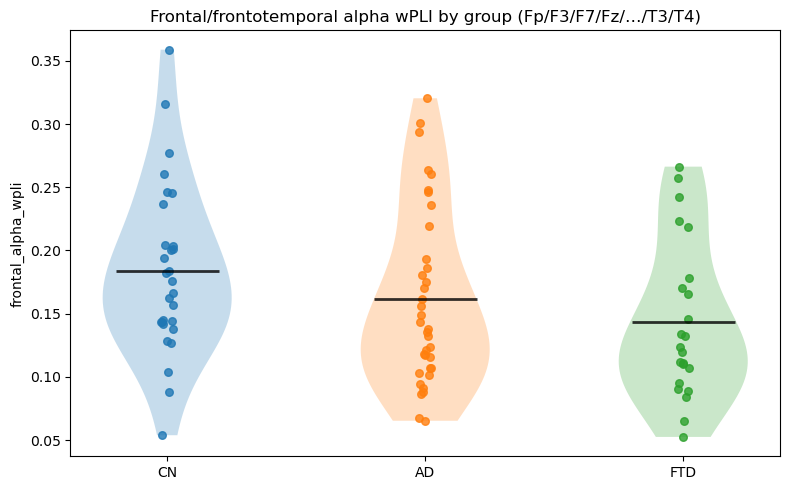

[INFO] Saved plot → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/block3/block3_frontal_alpha_violin.png


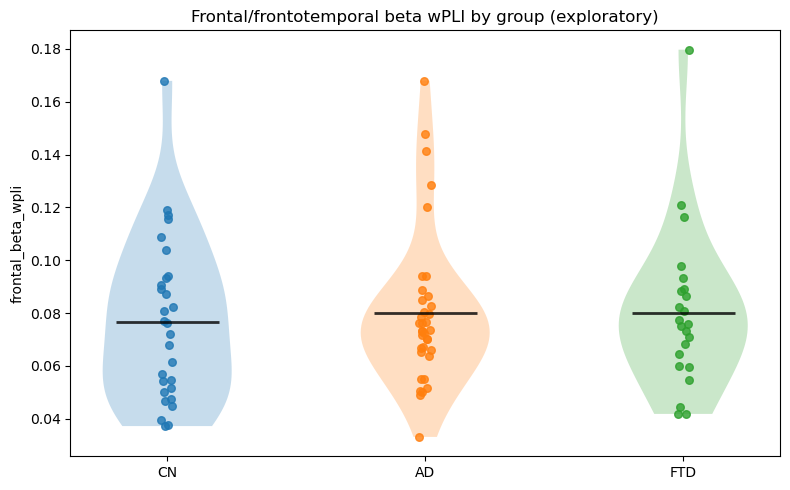

[INFO] Saved plot → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/block3/block3_frontal_beta_violin.png
[INFO] Block 3 complete.


In [1]:
# ===========================
# Block 3 — Frontal / Frontotemporal Connectivity (wPLI)
# Hypothesis 2 (FTD)
# ===========================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from mne_connectivity import spectral_connectivity_epochs  # confirmed available

# -----------------
# Config
# -----------------

ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")

DATA_ROOT = ROOT / "outputs"  # sub-001/, sub-002/, ...
OUTDIR = ROOT / "outputs" / "connectivity" / "block3"
OUTDIR.mkdir(parents=True, exist_ok=True)

PARTIC = ROOT / "participants.tsv"

# bands
ALPHA_FMIN, ALPHA_FMAX = 8.0, 13.0
BETA_FMIN,  BETA_FMAX  = 13.0, 30.0
METHOD = "wpli"

# epoch settings
EPOCH_LEN = 2.0  # seconds

# frontal / frontotemporal ROI for FTD hypothesis
ROI_CHANS = ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "Fz", "T3", "T4"]
# note: T3/T4 may already be renamed to T7/T8 in your data; we'll handle that rename like Block 2

# group map
GROUP_MAP = {
    "C": "CN",   # control
    "A": "AD",   # Alzheimer’s
    "F": "FTD",  # frontotemporal dementia
}
GROUP_ORDER = ["CN", "AD", "FTD"]  # we'll still plot all three for completeness


# -----------------
# Helpers (same style as Block 2)
# -----------------

def load_group_table(participants_path: Path) -> dict:
    """
    Read participants.tsv and build dict: '001' -> 'CN' / 'AD' / 'FTD'
    """
    dfp = pd.read_csv(participants_path, sep="\t")
    # 'sub-001' -> '001'
    dfp["sub_id_core"] = dfp["participant_id"].str.replace("^sub-", "", regex=True)
    dfp["group_pretty"] = dfp["Group"].map(GROUP_MAP)
    return dict(zip(dfp["sub_id_core"], dfp["group_pretty"]))


def epochs_for_subject(set_path: Path, roi_list: list[str], epoch_len_s: float):
    """
    Load one subject's cleaned .set, limit to ROI channels, segment into non-overlap epochs.

    Returns:
        epochs_roi (mne.Epochs) or None,
        picks_here (list of channel names actually found in this subject)
    """
    raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)

    # harmonize legacy temporal labels like Block 2
    rename_map = {"T3": "T7", "T4": "T8", "T5": "P7", "T6": "P8"}
    present = {old: new for old, new in rename_map.items() if old in raw.ch_names}
    if len(present) > 0:
        raw.rename_channels(present)

    # after rename, rebuild ROI list so T3/T4 -> T7/T8 if needed
    # our conceptual ROI was ["Fp1","Fp2","F3","F4","F7","F8","Fz","T3","T4"]
    # after rename, T3->T7, T4->T8
    roi_equiv = []
    for ch in roi_list:
        if ch == "T3" and "T7" in raw.ch_names:
            roi_equiv.append("T7")
        elif ch == "T4" and "T8" in raw.ch_names:
            roi_equiv.append("T8")
        else:
            roi_equiv.append(ch)

    # set montage so plots/positions later are possible if we ever want head plots
    try:
        raw.set_montage("standard_1020", match_case=False)
    except Exception as e:
        print(f"[WARN] montage set failed for {set_path.name}: {e}")

    # pick ROI actually present
    picks_here = [ch for ch in roi_equiv if ch in raw.ch_names]
    if len(picks_here) < 2:
        return None, picks_here  # can't do connectivity with <2 chans

    raw_roi = raw.copy().pick(picks_here)
    sfreq = raw_roi.info["sfreq"]

    # make consecutive 2s windows (same trick as Block 2)
    n_samples = raw_roi.n_times
    seglen = int(round(epoch_len_s * sfreq))
    onsets = np.arange(0, n_samples - seglen + 1, seglen, dtype=int)
    n_epochs = len(onsets)
    if n_epochs < 2:
        return None, picks_here

    events = np.c_[onsets,
                   np.zeros(n_epochs, dtype=int),
                   np.ones(n_epochs, dtype=int)]

    epochs_roi = mne.Epochs(
        raw_roi,
        events=events.astype(int),
        event_id={"dummy": 1},
        tmin=0.0,
        tmax=epoch_len_s - 1.0 / sfreq,
        baseline=None,
        preload=True,
        reject=None,
        verbose=False,
    )

    return epochs_roi, picks_here


def compute_wpli_matrix_band(epochs_obj,
                             fmin: float,
                             fmax: float,
                             method: str = "wpli"):
    """
    wPLI in [fmin,fmax] for all pairs.
    Returns dense (n_ch, n_ch).
    """
    data = epochs_obj.get_data()  # (n_epochs, n_ch, n_times)

    conn = spectral_connectivity_epochs(
        data,
        method=method,
        sfreq=epochs_obj.info["sfreq"],
        fmin=fmin,
        fmax=fmax,
        faverage=True,   # collapse across that band to 1 value per pair
        verbose=False,
    )

    mat = conn.get_data(output="dense")
    mat = np.squeeze(mat)  # (n_ch, n_ch) after squeeze
    return mat


def mean_offdiag(mat2d: np.ndarray) -> float:
    """
    Average all off-diagonal entries.
    """
    n = mat2d.shape[0]
    mask = ~np.eye(n, dtype=bool)
    return float(mat2d[mask].mean())


# -----------------
# Main loop
# -----------------

group_lookup = load_group_table(PARTIC)

rows = []  # per subject summary (alpha+beta)
# we’ll also keep per-group lists of alpha/beta matrices if we later want group-average
group_alpha_mats = {}
group_beta_mats = {}

for sub_dir in sorted(DATA_ROOT.glob("sub-*")):
    sub_id_core = sub_dir.name.replace("sub-", "")  # "001"

    if sub_id_core not in group_lookup:
        print(f"[WARN] cannot determine group for {sub_dir.name}, skip.")
        continue
    group_code = group_lookup[sub_id_core]  # "CN"/"AD"/"FTD"

    # find cleaned file
    set_files = sorted(sub_dir.glob("*cleaned_final.set"))
    if len(set_files) == 0:
        print(f"[WARN] {sub_dir.name}: no *_cleaned_final.set, skip.")
        continue
    set_path = set_files[0]

    # get epochs from frontal/frontotemporal ROI
    epochs_roi, picks_here = epochs_for_subject(set_path, ROI_CHANS, EPOCH_LEN)
    if epochs_roi is None or len(epochs_roi) < 2:
        print(f"[WARN] {sub_dir.name}: not enough usable epochs, skip.")
        continue

    # --- compute alpha connectivity matrix ---
    mat_alpha = compute_wpli_matrix_band(
        epochs_roi,
        fmin=ALPHA_FMIN,
        fmax=ALPHA_FMAX,
        method=METHOD
    )

    # safety check
    if mat_alpha.ndim != 2 or mat_alpha.shape[0] < 2 or mat_alpha.shape[0] != mat_alpha.shape[1]:
        print(f"[WARN] {sub_dir.name}: bad alpha wPLI matrix shape {mat_alpha.shape}, skip.")
        continue

    # --- compute beta connectivity matrix ---
    mat_beta = compute_wpli_matrix_band(
        epochs_roi,
        fmin=BETA_FMIN,
        fmax=BETA_FMAX,
        method=METHOD
    )

    if mat_beta.ndim != 2 or mat_beta.shape[0] < 2 or mat_beta.shape[0] != mat_beta.shape[1]:
        print(f"[WARN] {sub_dir.name}: bad beta wPLI matrix shape {mat_beta.shape}, skip.")
        continue

    # scalar scores (alpha primary, beta exploratory)
    alpha_strength = mean_offdiag(mat_alpha)
    beta_strength  = mean_offdiag(mat_beta)

    # store per-subject row
    rows.append({
        "subj": sub_id_core,
        "group": group_code,
        "frontal_alpha_wpli": alpha_strength,
        "frontal_beta_wpli":  beta_strength,
        "n_epochs": len(epochs_roi),
        "n_ch_roi": len(picks_here),
    })

    # save individual subject matrices (for debug / later plotting)
    np.save(
        OUTDIR / f"{sub_dir.name}_frontal_alpha_wpli.npy",
        mat_alpha
    )
    np.save(
        OUTDIR / f"{sub_dir.name}_frontal_beta_wpli.npy",
        mat_beta
    )

    # keep for per-group averaging
    group_alpha_mats.setdefault(group_code, []).append(mat_alpha)
    group_beta_mats.setdefault(group_code, []).append(mat_beta)


# -----------------
# Save summary CSV
# -----------------

df_block3 = pd.DataFrame(rows)
summary_csv_path = OUTDIR / "block3_frontal_connectivity_summary.csv"
df_block3.to_csv(summary_csv_path, index=False)
print(f"[INFO] Saved per-subject summary → {summary_csv_path}")

display(df_block3.head())


# -----------------
# Violin / scatter for alpha (primary FTD hypothesis: frontal alpha)
# -----------------

palette = {
    "CN": "#1f77b4",   # blue-ish
    "AD": "#ff7f0e",   # orange-ish
    "FTD": "#2ca02c",  # green-ish
}

def plot_violin(df, value_col, title, outfile):
    vals_by_group = []
    colors = []
    for g in GROUP_ORDER:
        these_vals = df.loc[df["group"] == g, value_col].dropna().values
        vals_by_group.append(these_vals)
        colors.append(palette.get(g, "gray"))

    fig, ax = plt.subplots(figsize=(8,5))

    parts = ax.violinplot(
        vals_by_group,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    # color the violins
    for pc, c in zip(parts['bodies'], colors):
        pc.set_facecolor(c)
        pc.set_alpha(0.25)
        pc.set_edgecolor('none')

    # scatter each subject + horizontal group mean
    for i, (grp, arr) in enumerate(zip(GROUP_ORDER, vals_by_group), start=1):
        if len(arr) == 0:
            continue
        # jittered subject dots
        ax.scatter(
            np.full_like(arr, i, dtype=float) + (np.random.rand(len(arr))-0.5)*0.05,
            arr,
            color=palette.get(grp, "gray"),
            s=30,
            alpha=0.8,
            zorder=3
        )
        # group mean line
        ax.hlines(
            y=np.mean(arr),
            xmin=i-0.2,
            xmax=i+0.2,
            color="black",
            linewidth=2,
            alpha=0.8,
            zorder=4
        )

    ax.set_xticks([1,2,3])
    ax.set_xticklabels(GROUP_ORDER)
    ax.set_ylabel(value_col)
    ax.set_title(title)

    fig.tight_layout()
    fig.savefig(outfile, dpi=300)
    plt.show()
    print(f"[INFO] Saved plot → {outfile}")


# Alpha plot (main story: CN vs FTD frontal alpha)
plot_violin(
    df_block3,
    value_col="frontal_alpha_wpli",
    title="Frontal/frontotemporal alpha wPLI by group (Fp/F3/F7/Fz/…/T3/T4)",
    outfile=OUTDIR / "block3_frontal_alpha_violin.png"
)

# Beta plot (exploratory: CN vs FTD frontal beta)
plot_violin(
    df_block3,
    value_col="frontal_beta_wpli",
    title="Frontal/frontotemporal beta wPLI by group (exploratory)",
    outfile=OUTDIR / "block3_frontal_beta_violin.png"
)


# -----------------
# Save per-group mean matrices (alpha & beta) for future plotting if we want later
# -----------------

for grp_code, mats in group_alpha_mats.items():
    if len(mats) == 0:
        continue
    mats_arr = np.stack(mats, axis=0)
    grp_mean_alpha = mats_arr.mean(axis=0)
    np.save(
        OUTDIR / f"group_{grp_code}_frontal_alpha_wpli_mean.npy",
        grp_mean_alpha
    )

for grp_code, mats in group_beta_mats.items():
    if len(mats) == 0:
        continue
    mats_arr = np.stack(mats, axis=0)
    grp_mean_beta = mats_arr.mean(axis=0)
    np.save(
        OUTDIR / f"group_{grp_code}_frontal_beta_wpli_mean.npy",
        grp_mean_beta
    )

print("[INFO] Block 3 complete.")


===== Alpha =====

[Classical ANOVA]
    Source        SS  DF        MS         F     p-unc       np2
0   group  0.021527   2  0.010763  2.404013  0.096474  0.053537
1  Within  0.380567  85  0.004477       NaN       NaN       NaN

[Pairwise comparisons]
   Contrast   A    B  Paired  Parametric         T        dof alternative  \
0    group  AD   CN   False        True -1.301715  61.115522   two-sided   
1    group  AD  FTD   False        True  1.060544  51.163711   two-sided   
2    group  CN  FTD   False        True  2.268016  48.770744   two-sided   

      p-unc    p-corr p-adjust   BF10     cohen  
0  0.197899  0.593698     bonf  0.521 -0.323224  
1  0.293878  0.881635     bonf   0.43  0.275445  
2  0.027793  0.083379     bonf  2.206  0.627470  

Descriptive stats:
            mean       std  count
group                           
AD     0.161561  0.069933     36
CN     0.183732  0.066881     29
FTD    0.143126  0.061846     23


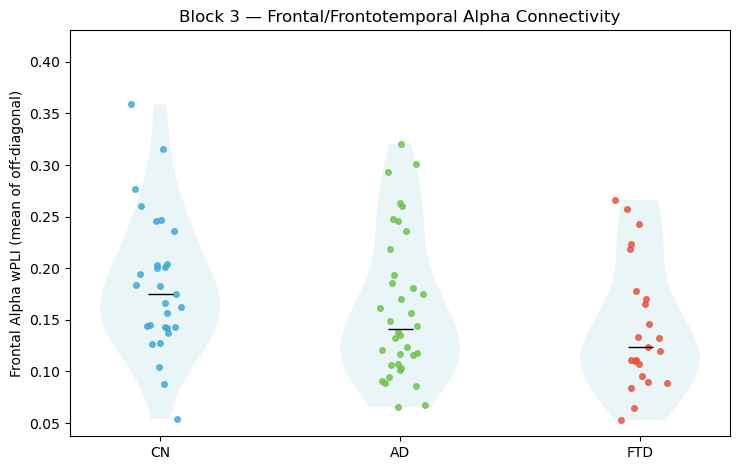

[i] Figure saved: /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block3/block3_frontal_alpha_stats_violin.png
[i] ANOVA: /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block3/block3_Alpha_ANOVA.csv
[i] Pairwise: /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block3/block3_Alpha_pairwise.csv

===== Beta =====

[Classical ANOVA]
    Source        SS  DF        MS         F     p-unc       np2
0   group  0.000218   2  0.000109  0.123005  0.884416  0.002886
1  Within  0.075215  85  0.000885       NaN       NaN       NaN

[Pairwise comparisons]
   Contrast   A    B  Paired  Parametric         T        dof alternative  \
0    group  AD   CN   False        True  0.445687  58.347240   two-sided   
1    group  AD  FTD   False        True -0.007840  45.631328   two-sided   
2    group  CN  FTD   False        True -0.399920  47.810945   two-sided   

      p-unc  p-c

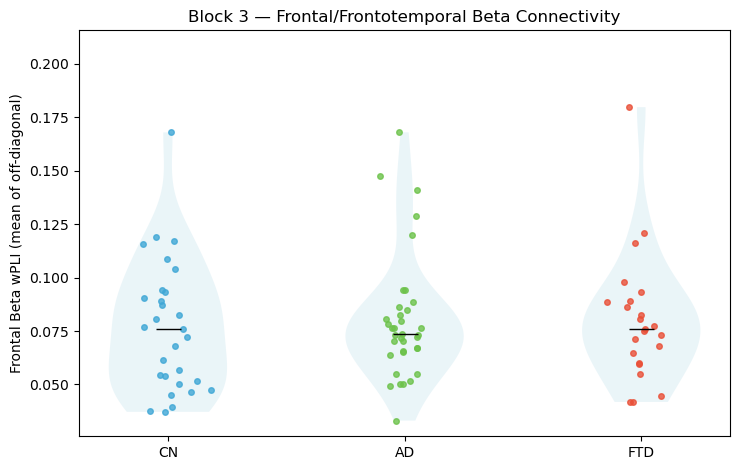

[i] Figure saved: /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block3/block3_frontal_beta_stats_violin.png
[i] ANOVA: /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block3/block3_Beta_ANOVA.csv
[i] Pairwise: /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block3/block3_Beta_pairwise.csv


In [2]:
# =====================================================
# Block 3: Group Statistics — Frontal / Frontotemporal Connectivity
# =====================================================
import pingouin as pg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# ---------- Paths ----------
ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
IN_CSV = ROOT / "outputs" / "connectivity" / "block3" / "block3_frontal_connectivity_summary.csv"
SAVE_DIR = ROOT / "outputs" / "connectivity" / "stats" / "block3"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Load ----------
merged = pd.read_csv(IN_CSV)

# =====================================================
# Helper function for one measure (Alpha / Beta)
# =====================================================
def run_stats_for_band(value_col: str, label: str):
    print(f"\n===== {label} =====")

    # Prepare working copy
    df = merged[["group", value_col]].copy()
    df.rename(columns={value_col: "global_wpli"}, inplace=True)

    # ---------- ANOVA ----------
    anova_res = pg.anova(data=df, dv="global_wpli", between="group", detailed=True)
    anova_path = SAVE_DIR / f"block3_{label.replace(' ', '_')}_ANOVA.csv"
    anova_res.to_csv(anova_path, index=False)
    print("\n[Classical ANOVA]\n", anova_res)

    # ---------- Pairwise ----------
    pairwise = pg.pairwise_tests(
        data=df, dv="global_wpli", between="group",
        padjust="bonf", effsize="cohen"
    )
    pairwise_path = SAVE_DIR / f"block3_{label.replace(' ', '_')}_pairwise.csv"
    pairwise.to_csv(pairwise_path, index=False)
    print("\n[Pairwise comparisons]\n", pairwise)

    # ---------- Summary ----------
    summary = df.groupby("group")["global_wpli"].agg(["mean", "std", "count"])
    print("\nDescriptive stats:\n", summary)

    # ---------- Significance vs CN ----------
    sig_results = []
    for _, row in pairwise.iterrows():
        if "CN" in (row["A"], row["B"]) and row["p-corr"] < 0.05:
            g1, g2 = row["A"], row["B"]
            if g1 != "CN":
                g1, g2 = g2, g1
            sig_results.append((g2, row["p-corr"]))

    def p_to_star(p):
        if p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        else:
            return ""

    # ---------- Visualization ----------
    order = ["CN", "AD", "FTD"]
    df["group"] = pd.Categorical(df["group"], categories=order, ordered=True)
    df = df.sort_values("group")

    plt.figure(figsize=(7.5, 4.8))
    groups = [g for g in order if g in set(df["group"])]
    data = [df.loc[df["group"] == g, "global_wpli"].values for g in groups]

    # Violin (light blue)
    parts = plt.violinplot(data, showmeans=False, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor("lightblue")
        pc.set_alpha(0.25)

    # Scatter dots per group
    dot_colors = ["#3FA7D6", "#6CC24A", "#E94F37"]  # CN blue, AD green, FTD red
    for i, (vals, c) in enumerate(zip(data, dot_colors), start=1):
        if len(vals) == 0:
            continue
        x = np.random.normal(loc=i, scale=0.05, size=len(vals))
        plt.plot(x, vals, "o", color=c, markersize=4, alpha=0.8)

    # Group medians
    medians = [np.median(v) if len(v) else np.nan for v in data]
    plt.plot(range(1, len(groups) + 1), medians, marker="_", linestyle="none",
             color="black", markersize=18)

    plt.xticks(range(1, len(groups) + 1), groups)
    plt.ylabel(f"Frontal {label} wPLI (mean of off-diagonal)")
    plt.title(f"Block 3 — Frontal/Frontotemporal {label} Connectivity")

    # ---------- Significance stars ----------
    ymax = max([np.max(v) for v in data if len(v) > 0])
    offset = ymax * 0.1
    for group, p in sig_results:
        star = p_to_star(p)
        if star:
            idx = order.index(group) + 1
            plt.text(idx, ymax + offset, star,
                     ha="center", va="bottom", fontsize=16,
                     color="black", fontweight="bold")

    plt.ylim(None, ymax + offset * 2)
    plt.tight_layout()

    # ---------- Save ----------
    fig_path = SAVE_DIR / f"block3_frontal_{label.lower().split()[0]}_stats_violin.png"
    plt.savefig(fig_path, dpi=160)
    plt.show()

    print(f"[i] Figure saved: {fig_path}")
    print(f"[i] ANOVA: {anova_path}")
    print(f"[i] Pairwise: {pairwise_path}")


# =====================================================
# Run separately for Alpha and Beta
# =====================================================
run_stats_for_band("frontal_alpha_wpli", "Alpha")
run_stats_for_band("frontal_beta_wpli", "Beta")


[i] Loaded 88 entries from block3_frontal_connectivity_summary.csv
   subj group  frontal_alpha_wpli  frontal_beta_wpli  n_epochs  n_ch_roi
0     1    AD            0.218953           0.147676       299         9
1     2    AD            0.246053           0.119975       396         9
2     3    AD            0.236120           0.071842       153         9
[Permutation ANOVA] Observed F = 2.404, p_perm = 0.0911


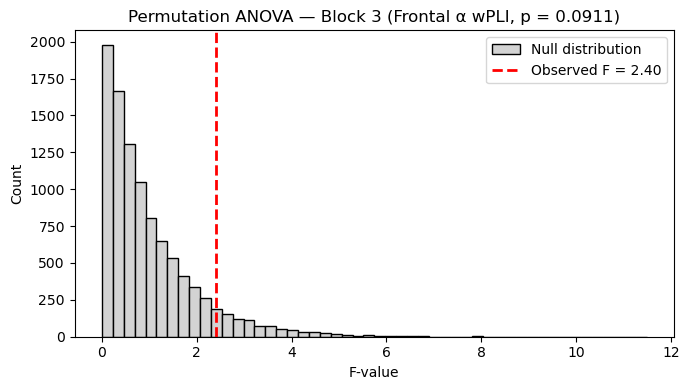

[i] Permutation histogram saved → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block3/block3_permutation_ANOVA_hist.png
[i] Summary text → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block3/block3_permutation_summary.txt


In [2]:
# =====================================================
# Block 3 — Permutation ANOVA (Frontal Alpha wPLI)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pingouin import anova
from pathlib import Path

# ---------- Paths ----------
ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
IN_CSV = ROOT / "outputs" / "connectivity" / "block3" / "block3_frontal_connectivity_summary.csv"
SAVE_DIR = ROOT / "outputs" / "connectivity" / "stats" / "block3"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Load ----------
df = pd.read_csv(IN_CSV)
df.rename(columns={"group": "group", "frontal_alpha_wpli": "frontal_alpha_wpli"}, inplace=True)
print(f"[i] Loaded {len(df)} entries from {IN_CSV.name}")
print(df.head(3))

# ---------- Permutation ANOVA ----------
def perm_anova(df, n_perm=10000, seed=42):
    np.random.seed(seed)
    real_F = anova(data=df, dv="frontal_alpha_wpli", between="group", detailed=True)["F"].values[0]
    perm_F = np.zeros(n_perm)
    for i in range(n_perm):
        shuffled = df.copy()
        shuffled["group"] = np.random.permutation(shuffled["group"].values)
        perm_F[i] = anova(data=shuffled, dv="frontal_alpha_wpli", between="group", detailed=True)["F"].values[0]
    p_perm = np.mean(perm_F >= real_F)
    return real_F, p_perm, perm_F

# ---------- Run ----------
real_F, p_perm, perm_F = perm_anova(df, n_perm=10000)
print(f"[Permutation ANOVA] Observed F = {real_F:.3f}, p_perm = {p_perm:.4f}")

# ---------- Save ----------
np.save(SAVE_DIR / "block3_permutation_Fdist.npy", perm_F)
with open(SAVE_DIR / "block3_permutation_summary.txt", "w") as f:
    f.write(f"Observed F = {real_F:.3f}\n")
    f.write(f"Permutation p = {p_perm:.5f}\n")
    f.write(f"n_perm = {len(perm_F)}\n")

# ---------- Visualization ----------
plt.figure(figsize=(7, 4))
plt.hist(perm_F, bins=50, color="lightgray", edgecolor="black", label="Null distribution")
plt.axvline(real_F, color="red", linestyle="--", lw=2, label=f"Observed F = {real_F:.2f}")
plt.xlabel("F-value")
plt.ylabel("Count")
plt.title(f"Permutation ANOVA — Block 3 (Frontal α wPLI, p = {p_perm:.4f})")
plt.legend()
plt.tight_layout()
out_path = SAVE_DIR / "block3_permutation_ANOVA_hist.png"
plt.savefig(out_path, dpi=300)
plt.show()

print(f"[i] Permutation histogram saved → {out_path}")
print(f"[i] Summary text → {SAVE_DIR / 'block3_permutation_summary.txt'}")


In [3]:
# =====================================================
# Block 3 — Graph-Theoretic Metrics + 95 % CIs (v2 add-on)
# =====================================================
import networkx as nx
import pingouin as pg
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
WPLI_DIR = ROOT / "outputs" / "connectivity" / "block3"
SAVE_DIR = ROOT / "outputs" / "connectivity" / "stats" / "block3"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Load main scores ----------
df = pd.read_csv(WPLI_DIR / "block3_frontal_connectivity_summary.csv")
print(f"[i] Loaded {len(df)} subjects for graph metrics")

# ---------- 1) Compute graph metrics per subject ----------
records = []
for _, row in df.iterrows():
    sid = row["subj"]
    npy_path = WPLI_DIR / f"sub-{int(sid):03d}_frontal_alpha_wpli.npy"
    if not npy_path.exists():
        print(f"[warn] Missing matrix for sub-{sid:03d}")
        continue

    W = np.load(npy_path)
    np.fill_diagonal(W, 0)
    G = nx.from_numpy_array(W)

    rec = {
        "subject": sid,
        "group": row["group"],
        "mean_degree": np.mean([d for _, d in G.degree(weight="weight")]),
        "global_eff": nx.global_efficiency(G),
        "clust_coeff": np.mean(list(nx.clustering(G, weight="weight").values()))
    }
    records.append(rec)

df_graph = pd.DataFrame(records)
graph_csv = SAVE_DIR / "block3_graph_metrics.csv"
df_graph.to_csv(graph_csv, index=False)
print(f"[i] Saved per-subject graph metrics → {graph_csv}")

# ---------- 2) ANOVA + pairwise for each graph metric ----------
for metric in ["mean_degree", "global_eff", "clust_coeff"]:
    aov = pg.anova(data=df_graph, dv=metric, between="group", detailed=True)
    pair = pg.pairwise_tests(
        data=df_graph,
        dv=metric,
        between="group",
        padjust="bonf",
        effsize="cohen"
    )
    aov.to_csv(SAVE_DIR / f"block3_{metric}_anova.csv", index=False)
    pair.to_csv(SAVE_DIR / f"block3_{metric}_pairwise.csv", index=False)
    print(f"[i] {metric}: ANOVA & pairwise tables saved")

# ---------- 3) 95 % bootstrap confidence intervals ----------
boot_n = 10000

# CI for group means (for figure captions)
ci_means = df.groupby("group")["frontal_alpha_wpli"].apply(
    lambda x: pg.compute_bootci(x, func="mean", n_boot=boot_n, seed=42)
)
ci_means.to_csv(SAVE_DIR / "block3_CI_means.csv")
print("[i] Saved 95 % CI for group means")

# CI for each pairwise Cohen's d
def boot_ci_d(x1, x2, n_boot=boot_n):
    return pg.compute_bootci(
        x1, func=lambda v: pg.compute_effsize(v, x2, eftype="cohen"),
        n_boot=n_boot, seed=42
    )

pairs = [("CN", "AD"), ("CN", "FTD"), ("AD", "FTD")]
ci_d = []
for g1, g2 in pairs:
    x1 = df.loc[df["group"] == g1, "frontal_alpha_wpli"]
    x2 = df.loc[df["group"] == g2, "frontal_alpha_wpli"]
    ci = boot_ci_d(x1, x2)
    ci_d.append({"contrast": f"{g1}-{g2}", "CI_low": ci[0], "CI_high": ci[1]})

ci_d_df = pd.DataFrame(ci_d)
ci_d_path = SAVE_DIR / "block3_CI_d.csv"
ci_d_df.to_csv(ci_d_path, index=False)
print(f"[i] Saved 95 % CI for effect sizes → {ci_d_path}")

print("[✓] Graph metrics + CI computation complete.")


[i] Loaded 88 subjects for graph metrics
[i] Saved per-subject graph metrics → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block3/block3_graph_metrics.csv
[i] mean_degree: ANOVA & pairwise tables saved
[i] global_eff: ANOVA & pairwise tables saved
[i] clust_coeff: ANOVA & pairwise tables saved
[i] Saved 95 % CI for group means


/Users/bohago/miniforge3/envs/eeg/lib/python3.11/site-packages/pingouin/parametric.py:1008: RuntimeWarning: invalid value encountered in scalar divide
  fval = msbetween / mserror
/Users/bohago/miniforge3/envs/eeg/lib/python3.11/site-packages/pingouin/parametric.py:1014: RuntimeWarning: invalid value encountered in scalar divide
  np2 = ssbetween / (ssbetween + sserror)  # = ssbetween / sstotal
/Users/bohago/miniforge3/envs/eeg/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/bohago/miniforge3/envs/eeg/lib/python3.11/site-packages/pingouin/effsize.py:803: RuntimeWarning: invalid value encountered in scalar divide
  d = (x.mean() - y.mean()) / poolsd
/Users/bohago/miniforge3/envs/eeg/lib/python3.11/site-packages/pingouin/effsize.py:803: RuntimeWarning: 

[i] Saved 95 % CI for effect sizes → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block3/block3_CI_d.csv
[✓] Graph metrics + CI computation complete.


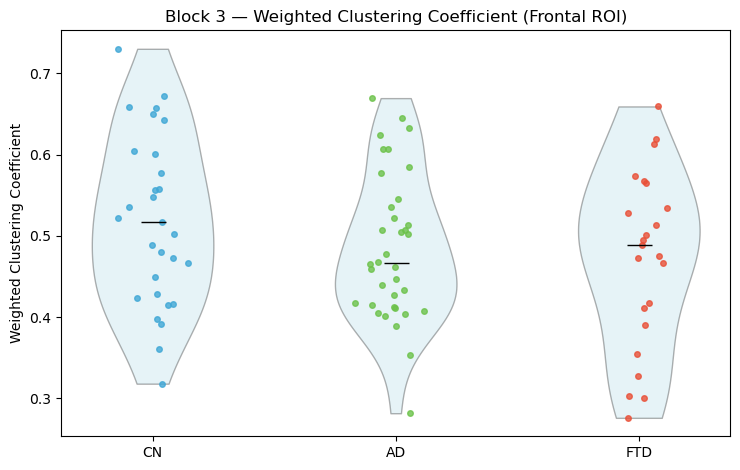

[✓] Figure saved → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block3/block3_clust_coeff_violin_match.png


In [4]:
# =====================================================
# Block 3 — Violin Plot of Clustering Coefficient
# =====================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
STATS_DIR = ROOT / "outputs" / "connectivity" / "stats" / "block3"

# ---------- Load ----------
df_graph = pd.read_csv(STATS_DIR / "block3_graph_metrics.csv")

order = ["CN", "AD", "FTD"]
df_graph["group"] = pd.Categorical(df_graph["group"], categories=order, ordered=True)
df_graph = df_graph.sort_values("group")

# ---------- Violin data ----------
groups = [g for g in order if g in set(df_graph["group"])]
data = [df_graph.loc[df_graph["group"] == g, "clust_coeff"].values for g in groups]

plt.figure(figsize=(7.5, 4.8))
parts = plt.violinplot(data, showmeans=False, showmedians=False, showextrema=False)

# --- styling: same as Block 1 & 2 ---
for pc in parts["bodies"]:
    pc.set_facecolor("lightblue")
    pc.set_edgecolor("black")
    pc.set_alpha(0.3)

# --- scatter points ---
dot_colors = ["#3FA7D6", "#6CC24A", "#E94F37"]  # CN, AD, FTD colors
for i, (vals, c) in enumerate(zip(data, dot_colors), start=1):
    if len(vals) == 0:
        continue
    x = np.random.normal(loc=i, scale=0.05, size=len(vals))
    plt.plot(x, vals, "o", color=c, markersize=4, alpha=0.8)

# --- medians ---
medians = [np.median(v) if len(v) else np.nan for v in data]
plt.plot(range(1, len(groups) + 1), medians, marker="_", linestyle="none",
         color="black", markersize=18)

# --- axis labels & title ---
plt.xticks(range(1, len(groups) + 1), groups)
plt.ylabel("Weighted Clustering Coefficient")
plt.title("Block 3 — Weighted Clustering Coefficient (Frontal ROI)")

plt.grid(False)
plt.tight_layout()

out_path = STATS_DIR / "block3_clust_coeff_violin_match.png"
plt.savefig(out_path, dpi=200)
plt.show()

print(f"[✓] Figure saved → {out_path}")
